In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , QuantileTransformer , RobustScaler

In [185]:
df=pd.read_csv("/content/drive/MyDrive/heart.csv")
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [186]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [189]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trtbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exng,0
oldpeak,0


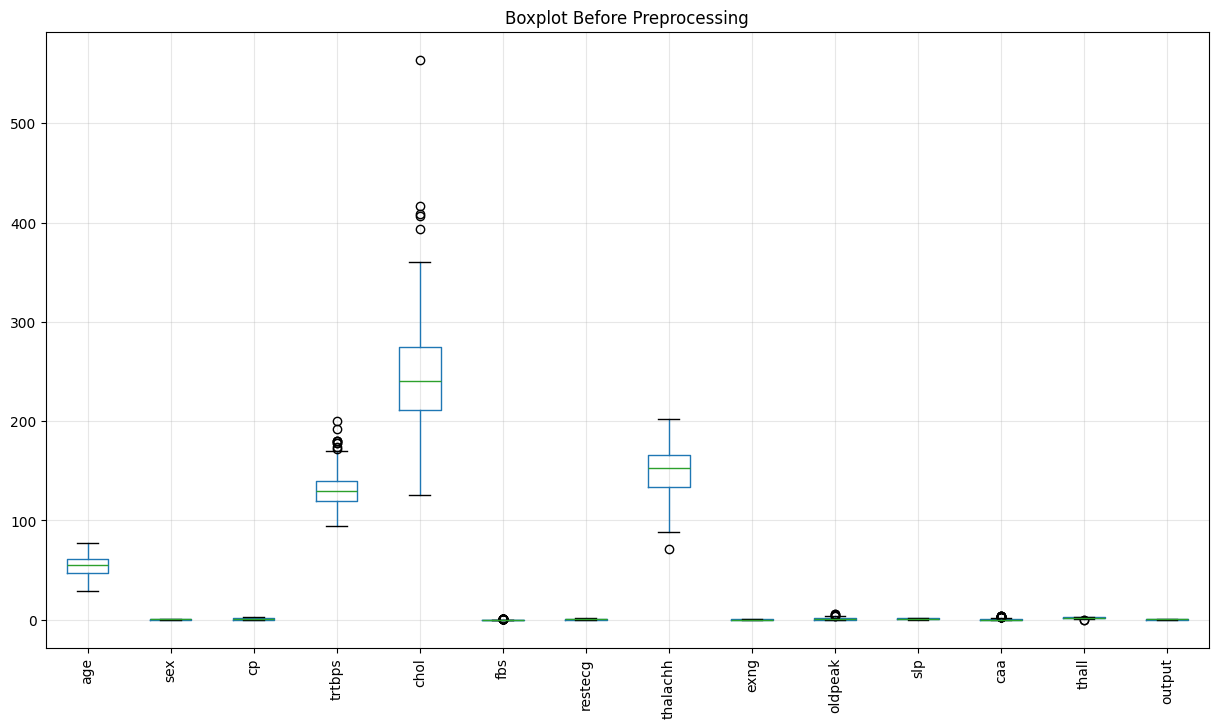

In [190]:
plt.figure(figsize=(15,8))

df.boxplot(rot=90)

plt.title("Boxplot Before Preprocessing")

plt.grid(alpha=0.3)
plt.show()

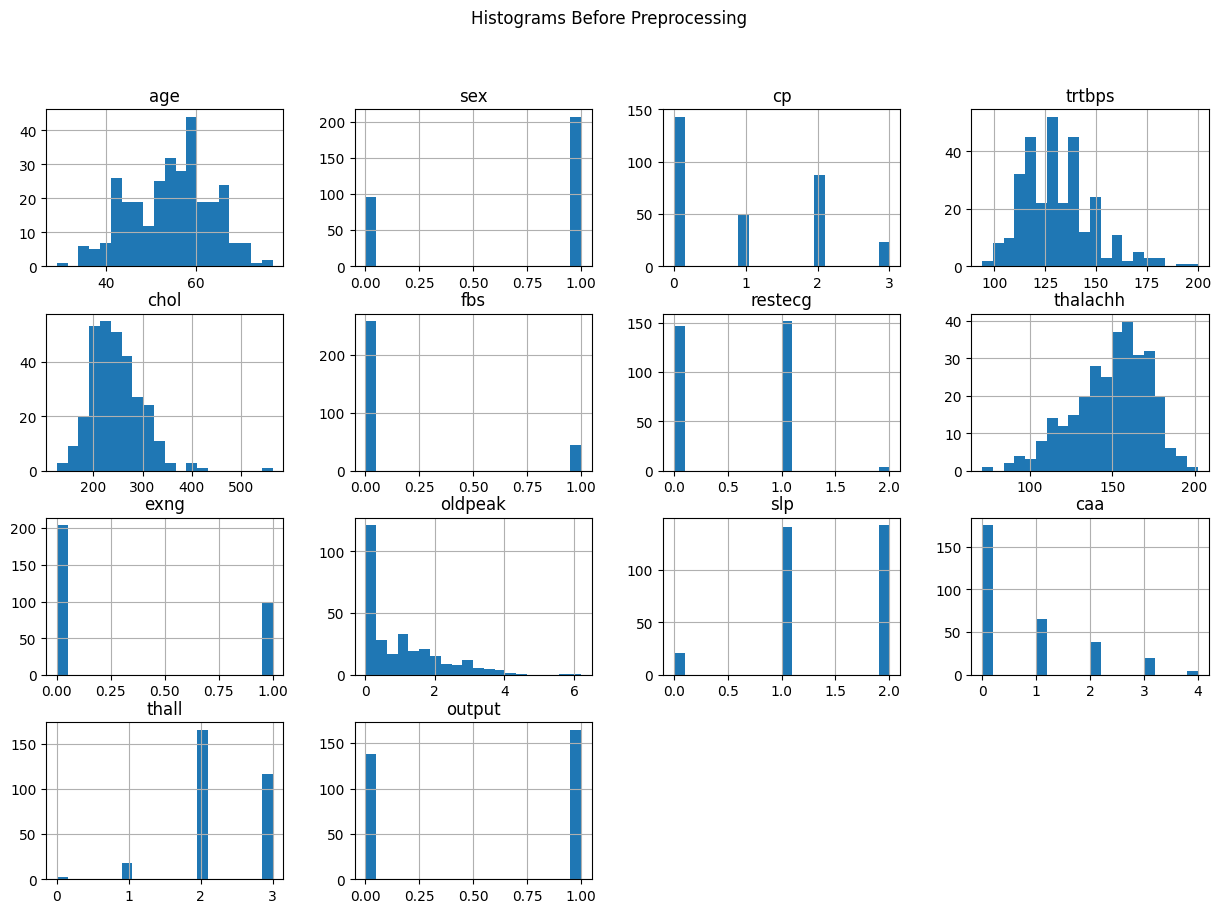

In [191]:
df.hist(figsize=(15,10), bins=20)

plt.suptitle("Histograms Before Preprocessing")

plt.show()

In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [193]:
for col in ['trtbps', 'chol', 'fbs', 'oldpeak' , 'thalachh' , 'caa' , 'thall']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df.loc[(df[col] < lower) | (df[col] > upper), col] = df[col].median()

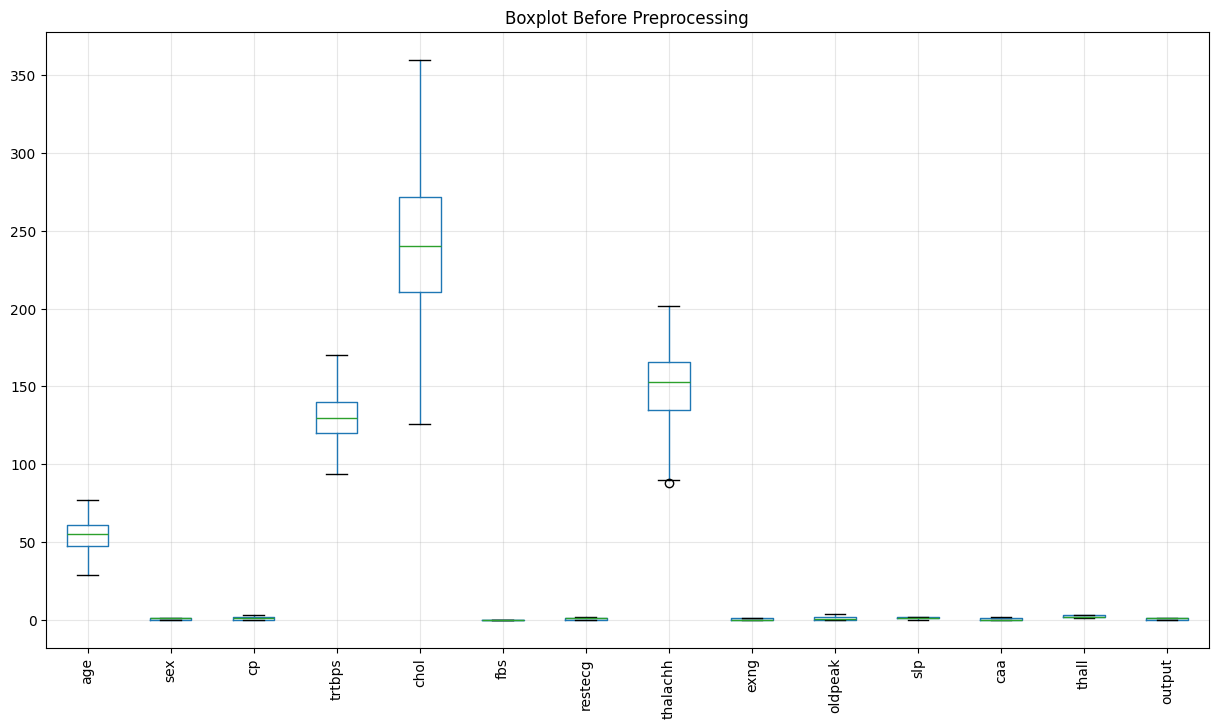

In [194]:
plt.figure(figsize=(15,8))

df.boxplot(rot=90)

plt.title("Boxplot Before Preprocessing")

plt.grid(alpha=0.3)
plt.show()

In [195]:
Q1 = df['thalachh'].quantile(0.25)
Q3 = df['thalachh'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df.loc[(df['thalachh'] < lower) | (df['thalachh'] > upper), col] = df['thalachh'].median()

<Axes: ylabel='thalachh'>

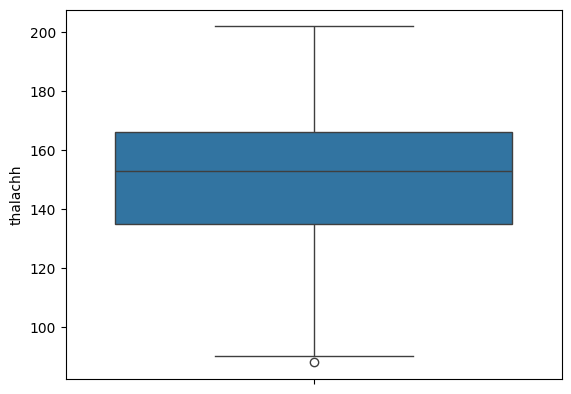

In [196]:
import seaborn as sns
sns.boxplot(df['thalachh'])

In [200]:
X = df.drop('output' , axis=1)
y = df['output']

In [201]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test= train_test_split(X , y , random_state=42 , test_size=0.2)

In [197]:
!pip install lazypredict

In [202]:
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0 , ignore_warnings=True , custom_metric=None)
models , predictions = clf.fit(X_train , X_test , y_train , y_test)
print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
BernoulliNB                    0.885246           0.885776  0.935345   
NearestCentroid                0.885246           0.885776  0.897629   
LinearSVC                      0.868852           0.870151  0.923491   
XGBClassifier                  0.868852           0.870151  0.906250   
LinearDiscriminantAnalysis     0.868852           0.866918  0.904095   
RidgeClassifier                0.868852           0.866918  0.904095   
RidgeClassifierCV              0.868852           0.866918  0.901940   
ExtraTreesClassifier           0.852459           0.852909  0.909483   
LGBMClassifier                 0.852459           0.852909  0.908405   
CalibratedClassifierCV         0.852459           0.852909  0.922414   
GaussianNB                     0.852459           0.848060  0.897629   
SGDClassifier                  0.836066           0.840517  0.92

In [203]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report , recall_score , precision_score , f1_score

In [204]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [205]:
model = LinearSVC(random_state=42, max_iter=5000)
model.fit(X_train, y_train)

LinearSVC(max_iter=5000, random_state=42)

In [206]:
y_pred = model.predict(X_test)

In [207]:
print("accuracy:", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

accuracy: 0.8688524590163934
precision: 0.9
recall: 0.84375
f1: 0.8709677419354839
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

